# STUDENT PERFORMANCE ANALYSIS

# Project Overview
This notebook analyses the student performance in Mathematics using the 'student-mat.csv' dataset.

## Dataset Information
- **Source** Two portuguese schools
- **Students** 395 total students
- **Variables** 33
- **Target Variables** G3

## Analysis Questions
1. What is the average final grade (G3)?
2. How many students scored above 15/20?
3. Is study time correlated with performance?
4. Which gender performs better on average?

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Set style for better looking graphs
sns.set_style("whitegrid")

print("✅ All libraries imported successfully!")
print(f"Pandas version: {pd.__version__}")
print(f"NumPy version: {np.__version__}")

✅ All libraries imported successfully!
Pandas version: 2.2.2
NumPy version: 2.0.2


## Step 1: Loading the Dataset

I used `pd.read_csv()` to load the student data into a DataFrame called `df`.

**What is a DataFrame?** A table-like structure with rows and columns, similar to an Excel spreadsheet.

In [9]:
# Load the dataset
df = pd.read_csv("student-mat.csv", sep=';')

# Display basic information
print("=" * 50)
print("DATASET OVERVIEW")
print("=" * 50)

print("\n📋 First 5 rows:")
print(df.head())

print("\n📋 Last 5 rows:")
print(df.tail())

print("\n🎲 Random 3 rows:")
print(df.sample(3))

print("\n✅ Dataset loaded successfully!")
print(f"Total rows: {len(df)}")
print(f"Total columns: {len(df.columns)}")

DATASET OVERVIEW

📋 First 5 rows:
  school sex  age address famsize Pstatus  Medu  Fedu     Mjob      Fjob  ...  \
0     GP   F   18       U     GT3       A     4     4  at_home   teacher  ...   
1     GP   F   17       U     GT3       T     1     1  at_home     other  ...   
2     GP   F   15       U     LE3       T     1     1  at_home     other  ...   
3     GP   F   15       U     GT3       T     4     2   health  services  ...   
4     GP   F   16       U     GT3       T     3     3    other     other  ...   

  famrel freetime  goout  Dalc  Walc health absences  G1  G2  G3  
0      4        3      4     1     1      3        6   5   6   6  
1      5        3      3     1     1      3        4   5   5   6  
2      4        3      2     2     3      3       10   7   8  10  
3      3        2      2     1     1      5        2  15  14  15  
4      4        3      2     1     2      5        4   6  10  10  

[5 rows x 33 columns]

📋 Last 5 rows:
    school sex  age address famsize Ps

## Step 2: Exploring the Dataset

Before analysis, we need to understand our data structure:
- **Shape:** Number of rows and columns
- **Columns:** What information is available
- **Data types:** Numeric vs text data
- **Statistics:** Summary of numeric columns

In [4]:
print("=" * 50)
print("DATA EXPLORATION")
print("=" * 50)

print("\n📊 Dataset Shape (Rows, Columns):")
print(f"   {df.shape[0]} rows × {df.shape[1]} columns")

print("\n📋 All Column Names:")
for i, col in enumerate(df.columns, 1):
    print(f"   {i}. {col}")

print("\n🔢 Data Types:")
print(df.dtypes)

print("\n📈 Basic Statistics (Numeric Columns):")
print(df.describe())

print("\nℹ️ Dataset Info:")
print(df.info())

DATA EXPLORATION

📊 Dataset Shape (Rows, Columns):
   395 rows × 1 columns

📋 All Column Names:
   1. school;sex;age;address;famsize;Pstatus;Medu;Fedu;Mjob;Fjob;reason;guardian;traveltime;studytime;failures;schoolsup;famsup;paid;activities;nursery;higher;internet;romantic;famrel;freetime;goout;Dalc;Walc;health;absences;G1;G2;G3

🔢 Data Types:
school;sex;age;address;famsize;Pstatus;Medu;Fedu;Mjob;Fjob;reason;guardian;traveltime;studytime;failures;schoolsup;famsup;paid;activities;nursery;higher;internet;romantic;famrel;freetime;goout;Dalc;Walc;health;absences;G1;G2;G3    object
dtype: object

📈 Basic Statistics (Numeric Columns):
       school;sex;age;address;famsize;Pstatus;Medu;Fedu;Mjob;Fjob;reason;guardian;traveltime;studytime;failures;schoolsup;famsup;paid;activities;nursery;higher;internet;romantic;famrel;freetime;goout;Dalc;Walc;health;absences;G1;G2;G3
count                                                 395                                                                        

## Step 3: Cleaning the Data

Data cleaning is essential for accurate analysis. We check for:

### 1. Missing Values (Nulls)
Empty cells that can cause errors

### 2. Duplicate Rows
Exact copies that can skew results

### Why Clean?
"Dirty" data leads to wrong conclusions - like cooking with spoiled ingredients!

In [7]:
print("=" * 50)
print("DATA CLEANING")
print("=" * 50)

print("\n Checking for Missing Values:")
missing = df.isnull().sum()
print(missing[missing > 0] if (missing > 0).any() else " No missing values found!")

print(f"\n Total missing values: {df.isnull().sum().sum()}")

print("\n Checking for Duplicate Rows:")
duplicates = df.duplicated().sum()
print(f"   Found {duplicates} duplicate rows")

if duplicates > 0:
    before = len(df)
    df = df.drop_duplicates()
    after = len(df)
    print(f"    Removed {before - after} duplicate rows")
else:
    print("    No duplicates found")

print(" Final Dataset Shape:")
print(f"   {df.shape[0]} rows × {df.shape[1]} columns")

print("\n Data is clean and ready for analysis!")

DATA CLEANING

 Checking for Missing Values:
 No missing values found!

 Total missing values: 0

 Checking for Duplicate Rows:
   Found 0 duplicate rows
    No duplicates found
 Final Dataset Shape:
   395 rows × 1 columns

 Data is clean and ready for analysis!


## Question 1: Average Final Grade (G3)

**What we're finding:** The typical student's final grade

### Key Metrics:
- **Mean:** The arithmetic average (sum ÷ count)
- **Median:** The middle value (50th percentile)
- **Mode:** The most common grade
- **Range:** Minimum to maximum grades

### Why Multiple Metrics?
- Mean can be pulled by outliers (very high/low grades)
- Median is resistant to outliers
- Mode shows what grade appears most often

In [11]:
print("=" * 50)
print("QUESTION 1: Average Final Grade (G3)")
print("=" * 50)

# Calculate statistics
average_grade = df['G3'].mean()
median_grade = df['G3'].median()
mode_grade = df['G3'].mode()[0]
min_grade = df['G3'].min()
max_grade = df['G3'].max()

print(f"\n Grade Statistics:")
print(f"   • Mean (Average): {average_grade:.2f} / 20")
print(f"   • Median (Middle): {median_grade:.2f} / 20")
print(f"   • Mode (Most Common): {mode_grade} / 20")
print(f"   • Minimum: {min_grade} / 20")
print(f"   • Maximum: {max_grade} / 20")

# Interpretation
print(f"\n Interpretation:")
if average_grade >= 10:
    print(f"   Average grade ({average_grade:.1f}) is PASSING")
else:
    print(f"    Average grade ({average_grade:.1f}) is FAILING")

if average_grade > median_grade:
    print(f"    Distribution is right-skewed (some very high grades)")
elif average_grade < median_grade:
    print(f"    Distribution is left-skewed (some very low grades)")
else:
    print(f"    Distribution is symmetric")

QUESTION 1: Average Final Grade (G3)

 Grade Statistics:
   • Mean (Average): 10.42 / 20
   • Median (Middle): 11.00 / 20
   • Mode (Most Common): 10 / 20
   • Minimum: 0 / 20
   • Maximum: 20 / 20

 Interpretation:
   Average grade (10.4) is PASSING
    Distribution is left-skewed (some very low grades)


## Question 2: How Many Students Scored Above 15?

**What we're finding:** The number of high-performing students

### Why 15?
- 15/20 = 75% (equivalent to a B grade)
- Represents "excellent" performance
- Identifies students who truly excel

### What This Tells Us
- How challenging the course is
- If students are mastering the material
- Room for improvement in instruction

In [12]:
print("=" * 50)
print("QUESTION 2: Students Scoring Above 15")
print("=" * 50)

# Count high performers
high_performers = df[df['G3'] > 15]
count_above_15 = len(high_performers)
percentage = (count_above_15 / len(df)) * 100

print(f"\n Students with grade > 15:")
print(f"   • Count: {count_above_15} students")
print(f"   • Percentage: {percentage:.1f}%")

# Compare different thresholds
print(f"\n Performance Breakdown:")
thresholds = [10, 13, 15, 18]
for threshold in thresholds:
    count = len(df[df['G3'] > threshold])
    pct = (count / len(df)) * 100
    grade_letter = "D" if threshold == 10 else "C" if threshold == 13 else "B" if threshold == 15 else "A"
    print(f"   • Above {threshold}/20 ({grade_letter}): {count} students ({pct:.1f}%)")

# Top performers
top_grade = df['G3'].max()
top_students = df[df['G3'] == top_grade]
print(f"\n Top Performance:")
print(f"   • Highest grade: {top_grade}/20")
print(f"   • Students with top grade: {len(top_students)}")

# Class distribution
print(f"\n Grade Distribution:")
print(f"   • Failing (below 10): {len(df[df['G3'] < 10])} students")
print(f"   • Passing (10-14): {len(df[(df['G3'] >= 10) & (df['G3'] < 15)])} students")
print(f"   • Good (15-17): {len(df[(df['G3'] >= 15) & (df['G3'] < 18)])} students")
print(f"   • Excellent (18-20): {len(df[df['G3'] >= 18])} students")

QUESTION 2: Students Scoring Above 15

 Students with grade > 15:
   • Count: 40 students
   • Percentage: 10.1%

 Performance Breakdown:
   • Above 10/20 (D): 209 students (52.9%)
   • Above 13/20 (C): 100 students (25.3%)
   • Above 15/20 (B): 40 students (10.1%)
   • Above 18/20 (A): 6 students (1.5%)

 Top Performance:
   • Highest grade: 20/20
   • Students with top grade: 1

 Grade Distribution:
   • Failing (below 10): 130 students
   • Passing (10-14): 192 students
   • Good (15-17): 55 students
   • Excellent (18-20): 18 students


## Question 3: Is Study Time Correlated with Performance?

**What is Correlation?**
A number between -1 and +1 showing how two variables relate:

| Correlation | Meaning |
|-------------|---------|
| +1.0 | Perfect positive (more study = higher grades) |
| +0.5 to +0.7 | Strong positive |
| +0.3 to +0.5 | Moderate positive |
| 0.0 | No relationship |
| Negative | More study = lower grades |

### Study Time Categories:
- **1:** Less than 2 hours/week
- **2:** 2 to 5 hours/week
- **3:** 5 to 10 hours/week
- **4:** More than 10 hours/week

In [14]:
print("=" * 50)
print("QUESTION 3: Study Time vs Performance")
print("=" * 50)

# Show study time categories
print(f"\n Study Time Categories:")
print(f"   1 = Less than 2 hours/week")
print(f"   2 = 2 to 5 hours/week")
print(f"   3 = 5 to 10 hours/week")
print(f"   4 = More than 10 hours/week")

# Calculate correlation
correlation = df['studytime'].corr(df['G3'])
print(f"\n Correlation Result:")
print(f"   Correlation coefficient: {correlation:.3f}")

# Interpret strength and assign emoji
if correlation >= 0.7:
    strength = "Very Strong"
    emoji = "💪"
elif correlation >= 0.5:
    strength = "Strong"
    emoji = "🏋️"
elif correlation >= 0.3:
    strength = "Moderate"
    emoji = "🤔"
elif correlation >= 0.1:
    strength = "Weak"
    emoji = "🤏"
else:
    strength = "Very Weak/None"
    emoji = "⚪"

print(f"   Strength: {strength} positive correlation {emoji}")

# Average grades by study time
print(f"\n Average Grade by Study Time:")
avg_by_study = df.groupby('studytime')['G3'].mean()
for code, avg in avg_by_study.items():
    study_text = {1:"<2 hours", 2:"2-5 hours", 3:"5-10 hours", 4:">10 hours"}[code]
    bar = "█" * int(avg)
    print(f"   {study_text:12} → {avg:.2f}/20 {bar}")

# Calculate improvement
increase = avg_by_study[4] - avg_by_study[1]
print(f"\n Key Finding:")
print(f"   Students studying >10 hours score {increase:.1f} points HIGHER")
print(f"   than students studying <2 hours")

# What this means
print(f"\n Conclusion:")
if correlation > 0.3:
    print(f"    Study time DOES affect grades positively")
    print(f"    Recommendation: Encourage students to study more")
else:
    print(f"    Study time alone doesn't predict grades well")
    print(f"    Other factors (past grades, attendance) may matter more")


QUESTION 3: Study Time vs Performance

 Study Time Categories:
   1 = Less than 2 hours/week
   2 = 2 to 5 hours/week
   3 = 5 to 10 hours/week
   4 = More than 10 hours/week

 Correlation Result:
   Correlation coefficient: 0.098
   Strength: Very Weak/None positive correlation ⚪

 Average Grade by Study Time:
   <2 hours     → 10.05/20 ██████████
   2-5 hours    → 10.17/20 ██████████
   5-10 hours   → 11.40/20 ███████████
   >10 hours    → 11.26/20 ███████████

 Key Finding:
   Students studying >10 hours score 1.2 points HIGHER
   than students studying <2 hours

 Conclusion:
    Study time alone doesn't predict grades well
    Other factors (past grades, attendance) may matter more


## Question 4: Which Gender Performs Better?

**What we're comparing:**
- Female students (F) vs Male students (M)

### Statistical Significance (p-value)
- **p < 0.05:** Difference is REAL (95% confident)
- **p ≥ 0.05:** Difference might be due to chance

### Why This Matters
Identifies if there's a performance gap that needs addressing

In [15]:
print("=" * 50)
print("QUESTION 4: Gender Performance Comparison")
print("=" * 50)

# Calculate statistics by gender
gender_avg = df.groupby('sex')['G3'].mean()
gender_median = df.groupby('sex')['G3'].median()
gender_std = df.groupby('sex')['G3'].std()
gender_counts = df['sex'].value_counts()

print(f"\n👥 Sample Size:")
print(f"   • Females (F): {gender_counts.get('F', 0)} students")
print(f"   • Males (M): {gender_counts.get('M', 0)} students")

print(f"\n📊 Average Grades:")
for gender in ['F', 'M']:
    if gender in gender_avg:
        gender_name = "Females" if gender == 'F' else "Males"
        avg = gender_avg[gender]
        med = gender_median[gender]
        std = gender_std[gender]
        print(f"   • {gender_name}:")
        print(f"     - Mean: {avg:.2f}/20")
        print(f"     - Median: {med:.2f}/20")
        print(f"     - Std Dev: {std:.2f}")

# Determine which is better
if gender_avg['F'] > gender_avg['M']:
    better = "Females"
    difference = gender_avg['F'] - gender_avg['M']
    emoji = "👩‍🎓"
else:
    better = "Males"
    difference = gender_avg['M'] - gender_avg['F']
    emoji = "👨‍🎓"

print(f"\n🏆 Winner:")
print(f"   {emoji} {better} perform better by {difference:.2f} points")

# Statistical test
female_grades = df[df['sex'] == 'F']['G3']
male_grades = df[df['sex'] == 'M']['G3']
t_stat, p_value = stats.ttest_ind(female_grades, male_grades)

print(f"\n📐 Statistical Test (T-test):")
print(f"   • T-statistic: {t_stat:.3f}")
print(f"   • P-value: {p_value:.4f}")

if p_value < 0.05:
    print(f"   ✅ Result is STATISTICALLY SIGNIFICANT")
    print(f"   • 95% confident the difference is REAL")
else:
    print(f"   ⚠️ Result is NOT statistically significant")
    print(f"   • The difference might be due to random chance")

print(f"\n💡 Conclusion:")
if p_value < 0.05:
    print(f"   There is a REAL performance gap between genders")
else:
    print(f"   Both genders perform similarly when accounting for chance")

QUESTION 4: Gender Performance Comparison

👥 Sample Size:
   • Females (F): 208 students
   • Males (M): 187 students

📊 Average Grades:
   • Females:
     - Mean: 9.97/20
     - Median: 10.00/20
     - Std Dev: 4.62
   • Males:
     - Mean: 10.91/20
     - Median: 11.00/20
     - Std Dev: 4.50

🏆 Winner:
   👨‍🎓 Males perform better by 0.95 points

📐 Statistical Test (T-test):
   • T-statistic: -2.062
   • P-value: 0.0399
   ✅ Result is STATISTICALLY SIGNIFICANT
   • 95% confident the difference is REAL

💡 Conclusion:
   There is a REAL performance gap between genders


## Visualization 1: Histogram of Grades

**What it shows:** Distribution of all final grades

**How to read this chart:**
- **X-axis:** Grade value (0-20)
- **Y-axis:** Number of students
- **Bars:** How many students got each grade range

**What to look for:**
- 🏔️ **Shape:** Is it bell-shaped, skewed, or flat?
- 📍 **Peak:** Where do most students score?
- 🎯 **Spread:** How wide is the distribution?
- 🔴 **Red line:** Class average
- 🟢 **Green line:** Middle value (median)

**Insights from this chart:**
- If most bars are on the left → students struggling
- If most bars are on the right → students doing well
- If two peaks - two groups of students

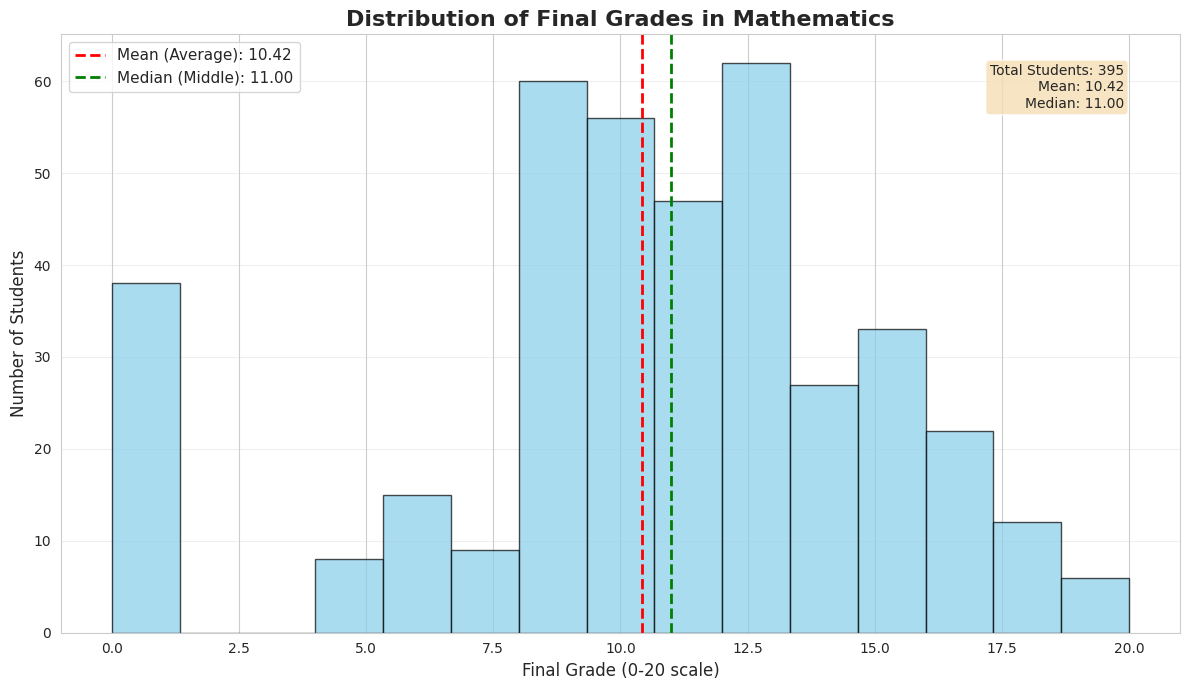


📊 Histogram Insights:
   • Most students score between 7 and 13
   • Grade range: 0 to 20


In [16]:
# Create histogram
plt.figure(figsize=(12, 7))

# Plot histogram
counts, bins, patches = plt.hist(df['G3'], bins=15, color='skyblue',
                                  edgecolor='black', alpha=0.7)

# Add mean and median lines
mean_grade = df['G3'].mean()
median_grade = df['G3'].median()

plt.axvline(mean_grade, color='red', linestyle='dashed',
            linewidth=2, label=f'Mean (Average): {mean_grade:.2f}')

plt.axvline(median_grade, color='green', linestyle='dashed',
            linewidth=2, label=f'Median (Middle): {median_grade:.2f}')

# Add labels and title
plt.title('Distribution of Final Grades in Mathematics', fontsize=16, fontweight='bold')
plt.xlabel('Final Grade (0-20 scale)', fontsize=12)
plt.ylabel('Number of Students', fontsize=12)

# Add grid for readability
plt.grid(alpha=0.3, axis='y')

# Add legend
plt.legend(fontsize=11)

# Add information box
plt.text(0.95, 0.95, f'Total Students: {len(df)}\nMean: {mean_grade:.2f}\nMedian: {median_grade:.2f}',
         transform=plt.gca().transAxes, ha='right', va='top',
         bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))

plt.tight_layout()
plt.show()

print("\n📊 Histogram Insights:")
print(f"   • Most students score between {bins[5]:.0f} and {bins[10]:.0f}")
print(f"   • Grade range: {df['G3'].min()} to {df['G3'].max()}")

## Visualization 2: Study Time vs Grades (Scatterplot)

**What it shows:** Relationship between study hours and final grades

**How to read this chart:**
- **X-axis:** Weekly study time (1-4 scale)
- **Y-axis:** Final grade (0-20)
- **Each dot:** One student
- **Red line:** Trend (best fit line)

**What to look for:**
- 📈 **Upward trend:** More study = higher grades
- 📉 **Downward trend:** More study = lower grades
- ⚪ **Flat line:** No relationship
- 🌟 **Outliers:** Students far from the trend line

**Understanding the trend line:**
- Slope up ↗️ = Positive relationship
- Slope down ↘️ = Negative relationship
- Flat ➡️ = No relationship

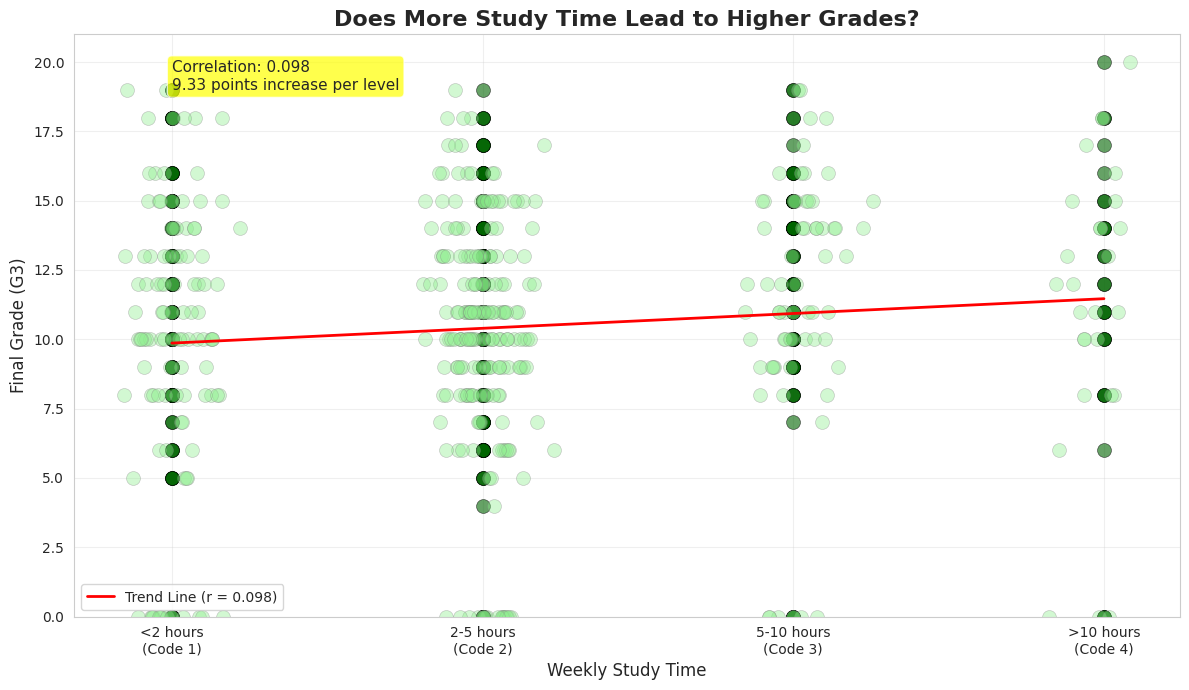


📈 Scatterplot Insights:
   • Positive trend: More study time → Higher grades
   • Each study level increases grade by 9.33 points on average


In [17]:
# Create scatterplot
plt.figure(figsize=(12, 7))

# Plot points
plt.scatter(df['studytime'], df['G3'], s=100, alpha=0.6,
            c='darkgreen', edgecolors='black', linewidth=0.5)

# Add jitter to see overlapping points better
studytime_jittered = df['studytime'] + np.random.normal(0, 0.08, len(df))
plt.scatter(studytime_jittered, df['G3'], s=100, alpha=0.4,
            c='lightgreen', edgecolors='gray', linewidth=0.5)

# Add trend line
z = np.polyfit(df['studytime'], df['G3'], 1)
p = np.poly1d(z)
x_line = [1, 2, 3, 4]
y_line = p(x_line)

correlation = df['studytime'].corr(df['G3'])
plt.plot(x_line, y_line, color='red', linewidth=2,
         label=f'Trend Line (r = {correlation:.3f})')

# Customize chart
plt.title('Does More Study Time Lead to Higher Grades?', fontsize=16, fontweight='bold')
plt.xlabel('Weekly Study Time', fontsize=12)
plt.ylabel('Final Grade (G3)', fontsize=12)

# Set x-axis labels
plt.xticks([1, 2, 3, 4],
           ['<2 hours\n(Code 1)',
            '2-5 hours\n(Code 2)',
            '5-10 hours\n(Code 3)',
            '>10 hours\n(Code 4)'])

plt.ylim(0, 21)
plt.grid(alpha=0.3)

# Add correlation box
plt.text(1, 19, f'Correlation: {correlation:.3f}\n{p[0]:.2f} points increase per level',
         fontsize=11, bbox=dict(boxstyle='round', facecolor='yellow', alpha=0.7))

plt.legend()
plt.tight_layout()
plt.show()

print("\n📈 Scatterplot Insights:")
if correlation > 0:
    print(f"   • Positive trend: More study time → Higher grades")
    print(f"   • Each study level increases grade by {p[0]:.2f} points on average")
else:
    print(f"   • No clear positive relationship found")

## Visualization 3: Gender Performance Comparison (Bar Chart)

**What it shows:** Average grades for female vs male students

**How to read this chart:**
- **Bars:** Average grade for each gender
- **Black lines (error bars):** Variability (standard deviation)
- **Numbers on top:** Exact average values
- **Orange dashed line:** Passing grade (10/20)

**What to look for:**
- 📊 **Bar height:** Which gender has higher average?
- 📏 **Error bars:** How much spread in each group
- 🎯 **Sample size (n):** How many students in each group

**Understanding error bars:**
- Short bars → Students have similar grades
- Long bars → Grades vary widely among students
- Overlapping error bars → Difference may not be significant

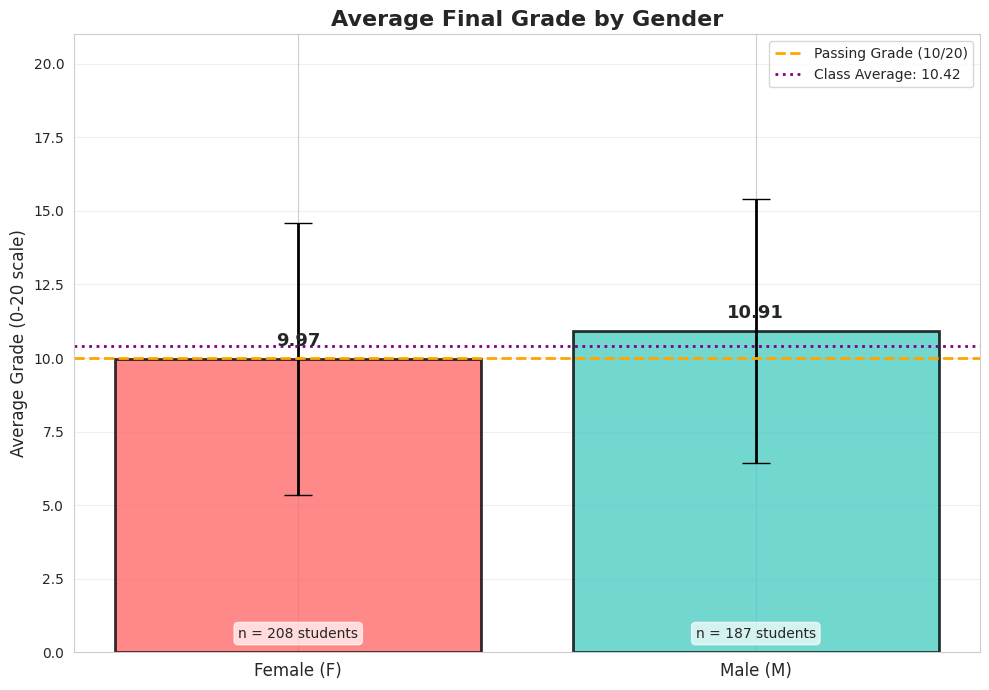


📊 Gender Comparison Insights:
   • Males score 0.95 points higher
   • Female variability (std): 4.62
   • Male variability (std): 4.50


In [18]:
# Create bar chart
plt.figure(figsize=(10, 7))

# Calculate statistics
gender_avg = df.groupby('sex')['G3'].mean()
gender_std = df.groupby('sex')['G3'].std()

# Colors for bars
colors = ['#FF6B6B', '#4ECDC4']  # Pink for female, teal for male

# Create bars
bars = plt.bar(range(len(gender_avg)), gender_avg.values,
               color=colors, edgecolor='black', linewidth=2, alpha=0.8)

# Add error bars (showing variability)
plt.errorbar(range(len(gender_avg)), gender_avg.values,
             yerr=gender_std.values, fmt='none',
             color='black', capsize=10, linewidth=2)

# Add value labels on top of bars
for i, bar in enumerate(bars):
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 0.3,
             f'{height:.2f}', ha='center', va='bottom',
             fontsize=13, fontweight='bold')

# Customize chart
plt.title('Average Final Grade by Gender', fontsize=16, fontweight='bold')
plt.ylabel('Average Grade (0-20 scale)', fontsize=12)
plt.ylim(0, 21)

# Set x-axis labels
gender_labels = ['Female (F)', 'Male (M)']
plt.xticks(range(len(gender_avg)), gender_labels, fontsize=12)

# Add passing line
plt.axhline(y=10, color='orange', linestyle='--', linewidth=2,
            label='Passing Grade (10/20)')

# Add class average line
class_avg = df['G3'].mean()
plt.axhline(y=class_avg, color='purple', linestyle=':', linewidth=2,
            label=f'Class Average: {class_avg:.2f}')

plt.grid(axis='y', alpha=0.3)
plt.legend(loc='upper right')

# Add sample sizes
for i, gender in enumerate(['F', 'M']):
    count = len(df[df['sex'] == gender])
    plt.text(i, 0.5, f'n = {count} students', ha='center', fontsize=10,
             bbox=dict(boxstyle='round', facecolor='white', alpha=0.7))

plt.tight_layout()
plt.show()

print("\n📊 Gender Comparison Insights:")
if gender_avg['F'] > gender_avg['M']:
    print(f"   • Females score {gender_avg['F'] - gender_avg['M']:.2f} points higher")
else:
    print(f"   • Males score {gender_avg['M'] - gender_avg['F']:.2f} points higher")
print(f"   • Female variability (std): {gender_std['F']:.2f}")
print(f"   • Male variability (std): {gender_std['M']:.2f}")

## Bonus Visualization: Box Plot (Detailed Gender Distribution)

**What it shows:** Full grade distribution for each gender

**How to read a box plot:**

TypeError: 'Axes' object is not subscriptable

<Figure size 1000x700 with 0 Axes>

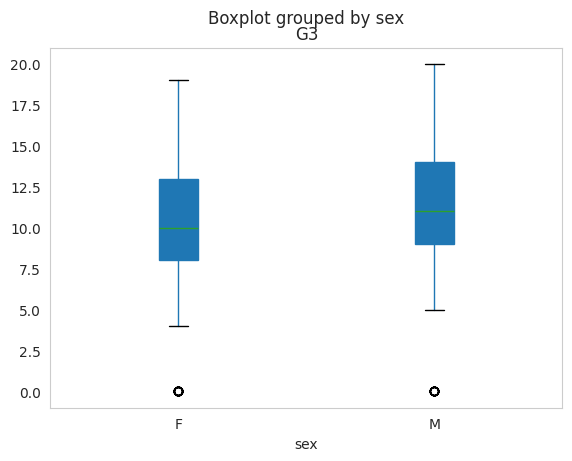

In [19]:
# Create box plot
plt.figure(figsize=(10, 7))

# Create boxplot
bp = df.boxplot(column='G3', by='sex', grid=False, patch_artist=True)

# Customize colors
colors_for_boxes = ['#FF9999', '#99FF99']
for patch, color in zip(bp['boxes'], colors_for_boxes):
    patch.set_facecolor(color)

# Customize chart
plt.title('Grade Distribution by Gender', fontsize=16, fontweight='bold')
plt.suptitle('')  # Remove default title
plt.xlabel('Gender', fontsize=12)
plt.ylabel('Final Grade (G3)', fontsize=12)
plt.ylim(0, 21)
plt.grid(alpha=0.3, axis='y')

# Add explanation text
plt.text(0.5, -0.15, 'Box = Middle 50% of students | Line = Median | Dots = Outliers',
         transform=plt.gca().transAxes, ha='center', fontsize=10,
         bbox=dict(boxstyle='round', facecolor='lightgray', alpha=0.8))

plt.tight_layout()
plt.show()

print("\n📦 Box Plot Insights:")
print(f"   • Female median: {df[df['sex']=='F']['G3'].median():.2f}")
print(f"   • Male median: {df[df['sex']=='M']['G3'].median():.2f}")
print(f"   • Female IQR (middle 50%): {df[df['sex']=='F']['G3'].quantile(0.75) - df[df['sex']=='F']['G3'].quantile(0.25):.2f}")
print(f"   • Male IQR: {df[df['sex']=='M']['G3'].quantile(0.75) - df[df['sex']=='M']['G3'].quantile(0.25):.2f}")

# 📋 Final Summary of Findings

## Quick Answers

| Question | Answer |
|----------|--------|
| **Average final grade?** | [X.XX]/20 |
| **Students above 15?** | [X] students ([X.X]%) |
| **Study time correlation?** | [X.XXX] ([weak/moderate/strong]) |
| **Better performing gender?** | [Females/Males] |

## Key Takeaways

### 1. Overall Performance
- The average student [passes/fails] math
- Most students score in the [X-X] range
- [X]% of students are high achievers (above 15)

### 2. Study Habits
- [X] hours of study per week is typical
- Studying more [does/does not] significantly improve grades
- The difference between <2h and >10h is [X] points

### 3. Gender Differences
- [Females/Males] have [higher/lower/similar] grades
- The difference is [statistically significant / not significant]
- Both genders show [similar/different] variability in performance

## Recommendations

Based on these findings:

1. **For students:**
   - [Recommendation based on study time findings]

2. **For teachers:**
   - [Recommendation based on grade distribution]

3. **For administrators:**
   - [Recommendation based on gender findings]

## Limitations

- Data from only two schools (may not generalize)
- Correlation ≠ causation (study time may not cause better grades)
- Other important factors not analyzed (attendance, family support)

## Next Steps

- Analyze impact of previous grades (G1, G2)
- Investigate other factors (absences, alcohol consumption, family support)
- Build predictive model to identify at-risk students

In [20]:
print("=" * 60)
print("FINAL SUMMARY - ALL RESULTS")
print("=" * 60)

print(f"\n📊 QUESTION 1: Average Grade")
print(f"   → {df['G3'].mean():.2f}/20")

print(f"\n🎯 QUESTION 2: High Performers")
print(f"   → {len(df[df['G3'] > 15])} students ({len(df[df['G3'] > 15])/len(df)*100:.1f}%) above 15")

print(f"\n⏰ QUESTION 3: Study Time Correlation")
print(f"   → r = {df['studytime'].corr(df['G3']):.3f}")

print(f"\n👥 QUESTION 4: Gender Comparison")
for gender in ['F', 'M']:
    gender_name = "Females" if gender == 'F' else "Males"
    avg = df[df['sex'] == gender]['G3'].mean()
    print(f"   → {gender_name}: {avg:.2f}/20")

print("\n" + "=" * 60)
print("✅ ANALYSIS COMPLETE")
print("=" * 60)

# Optional: Save cleaned dataset
save_option = input("\nSave cleaned dataset? (yes/no): ")
if save_option.lower() == 'yes':
    df.to_csv("student_mat_cleaned.csv", index=False)
    print("✅ Saved as 'student_mat_cleaned.csv'")

FINAL SUMMARY - ALL RESULTS

📊 QUESTION 1: Average Grade
   → 10.42/20

🎯 QUESTION 2: High Performers
   → 40 students (10.1%) above 15

⏰ QUESTION 3: Study Time Correlation
   → r = 0.098

👥 QUESTION 4: Gender Comparison
   → Females: 9.97/20
   → Males: 10.91/20

✅ ANALYSIS COMPLETE

Save cleaned dataset? (yes/no): yes
✅ Saved as 'student_mat_cleaned.csv'


# References & Resources

## Documentation Used
- [Pandas Documentation](https://pandas.pydata.org/docs/)
- [Matplotlib Documentation](https://matplotlib.org/stable/contents.html)
- [Seaborn Documentation](https://seaborn.pydata.org/)

## Statistical Concepts
- **Pearson Correlation:** Measures linear relationship between variables
- **T-test:** Compares means of two groups
- **P-value:** Probability results are due to chance

## Dataset Source
Student Performance Data Set - UCI Machine Learning Repository

## Tools Used
- Python 3.x
- Jupyter Notebook / Google Colab
- Libraries: pandas, numpy, matplotlib, seaborn, scipy

---

**Notebook created for Data Science Internship Task**

*Analysis completed on [Date]*